In [ ]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [4]:
df_flight_activity = pd.read_csv("files_limpios/customer_flight_activity_limpio.csv")

df_flight_activity.head(3)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0.0,0
1,100102,2017,1,10,4,14,2030,203.0,0.0,0
2,100140,2017,1,6,0,6,1200,120.0,0.0,0


In [5]:
df_loyalty = pd.read_csv("files_limpios/customer_loyalty_history_limpio.csv")

df_loyalty.head(3)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.000000,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79429.572642,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,79429.572642,Single,Star,3839.75,Standard,2014,7,2018.0,1.0


In [2]:
df_unido = pd.read_csv("files_limpios/customer_completo_limpio.csv")

df_unido.head(5)

NameError: name 'pd' is not defined

# 2) Análisis Estadístico:

### 1. Estadísticas descriptivas de las variables numéricas:  

###  media, mediana, desviación estándar

In [15]:
df_unido.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.000000,772152.00,999986.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.000000,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.000000,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.000000,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.000000,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.000000,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.000000,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.000000,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.000000,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.000000,0.00,71.00


#### Variables númericas relevantes

Trabajaremos con estas variables numéricas:

* `flights_booked`
* `distance`
* `points_accumulated`
* `points_redeemed`
* `salary`
* `clv`


In [35]:
variables_numericas = ["flights_booked", "distance", "points_accumulated", "points_redeemed", "salary","clv"]

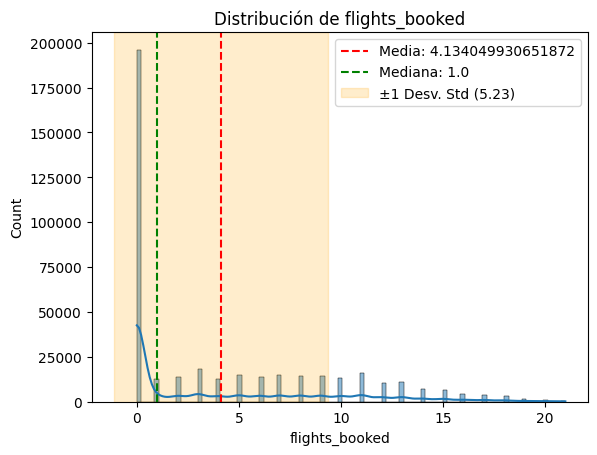

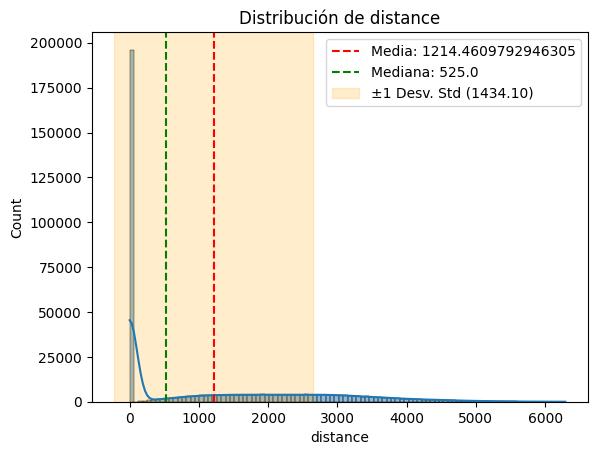

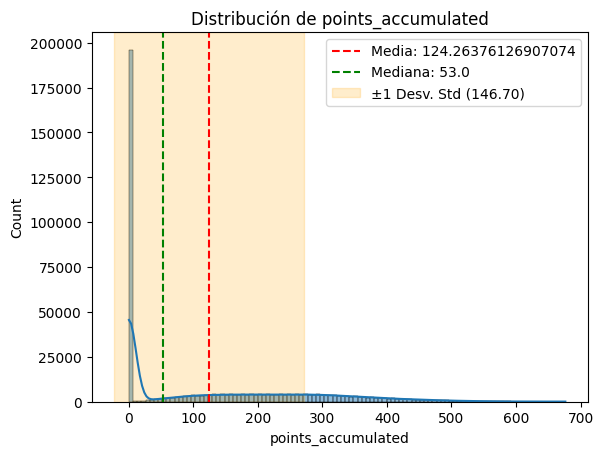

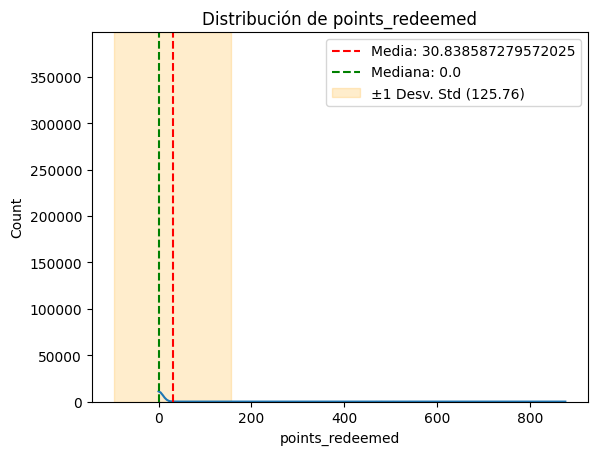

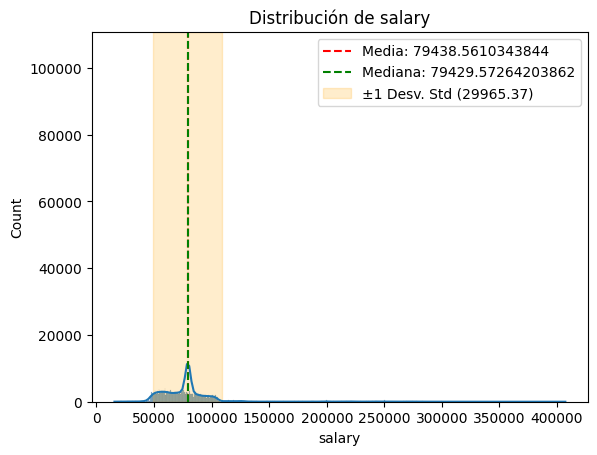

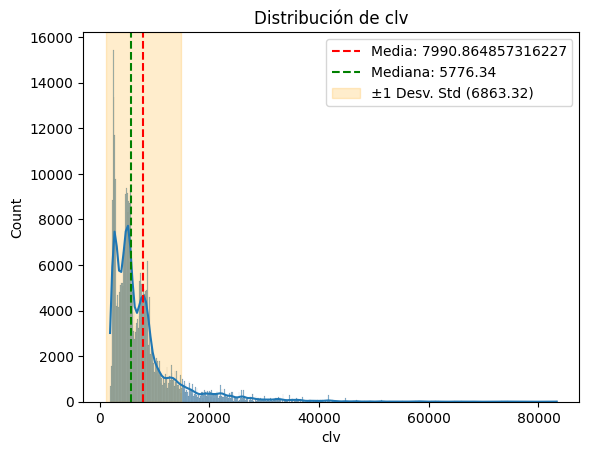

In [38]:
for col in variables_numericas:
# metricas de tendencia central
    media = df_unido[col].mean()
    mediana = df_unido[col].median()
# metrica de dispersion
    desv_std = df_unido[col].std()

    sns.histplot(df_unido[col], kde=True)
    plt.axvline(media, color='red', linestyle='--', label=f'Media: {media}')
    plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana}')

# área sombreada para ±1 desviación estándar
    plt.axvspan(media - desv_std, media + desv_std, 
                alpha=0.2, color='orange', label=f'±1 Desv. Std ({desv_std:.2f})')
    plt.title(f"Distribución de {col}") 

    plt.legend()
    plt.show()

In [ ]:
# La distribucion de flights_booked, distance, points_accumulated y points_redeemed tienen sesgo hacia la derecha (positivo). 
# La distribucion de salary es simétrica. 
# La distribucion de clv tiene sesgo a la derecha tambien.

# Esto nos indica que estas variables, a excepción de salary, se ven afectadas por los outliers
# En la misma linea la desviacion estandar alta indica que los valores están más dispersos alrededor de la media, (solo en salary es menor)


### 2. Valores atípicos en variables numéricas.

In [ ]:
# numero de outliers por variable numerica

for col in variables_numericas:
    Q1 = df_unido[col].quantile(0.25)
    Q3 = df_unido[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = df_unido[(df_unido[col] < lower) | (df_unido[col] > upper)].shape[0]

    print(f"{col}: {n_outliers} outliers")

flights_booked: 528 outliers
distance: 125 outliers
points_accumulated: 112 outliers
points_redeemed: 24181 outliers
salary: 20684 outliers
clv: 35941 outliers


In [37]:
# vemos que hay bastantes outliers pero que proporcion del total representan por variable?

for col in variables_numericas:
    Q1 = df_unido[col].quantile(0.25)
    Q3 = df_unido[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_unido[(df_unido[col] < lower) | (df_unido[col] > upper)]

    porcentaje = (outliers.shape[0] / df_unido.shape[0]) * 100

    print(f"{col}: {porcentaje:.2f}% de outliers")

flights_booked: 0.13% de outliers
distance: 0.03% de outliers
points_accumulated: 0.03% de outliers
points_redeemed: 5.99% de outliers
salary: 5.12% de outliers
clv: 8.90% de outliers


In [ ]:
# Los % indican que las variables points_redeemed, salary y clv tienen un % elevado de outliers lo que podria indicar:

# salary --> pocos clientes con ingresos extremos (bajos como altos)
# points_redeemed --> comportamientos variados de ciertos clientes
# clv --> clientes con bastante valor

In [1]:
# Cálculo de estadísticas descriptivas por nivel educativo
analisis = df_unido.groupby('education')['salary'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desviación Estándar', 'std'),
    ('Varianza', 'var'),
    ('Total', 'count')
])

display(analisis)

NameError: name 'df_unido' is not defined

### 3. Análisis de correlación entre variables numéricas.

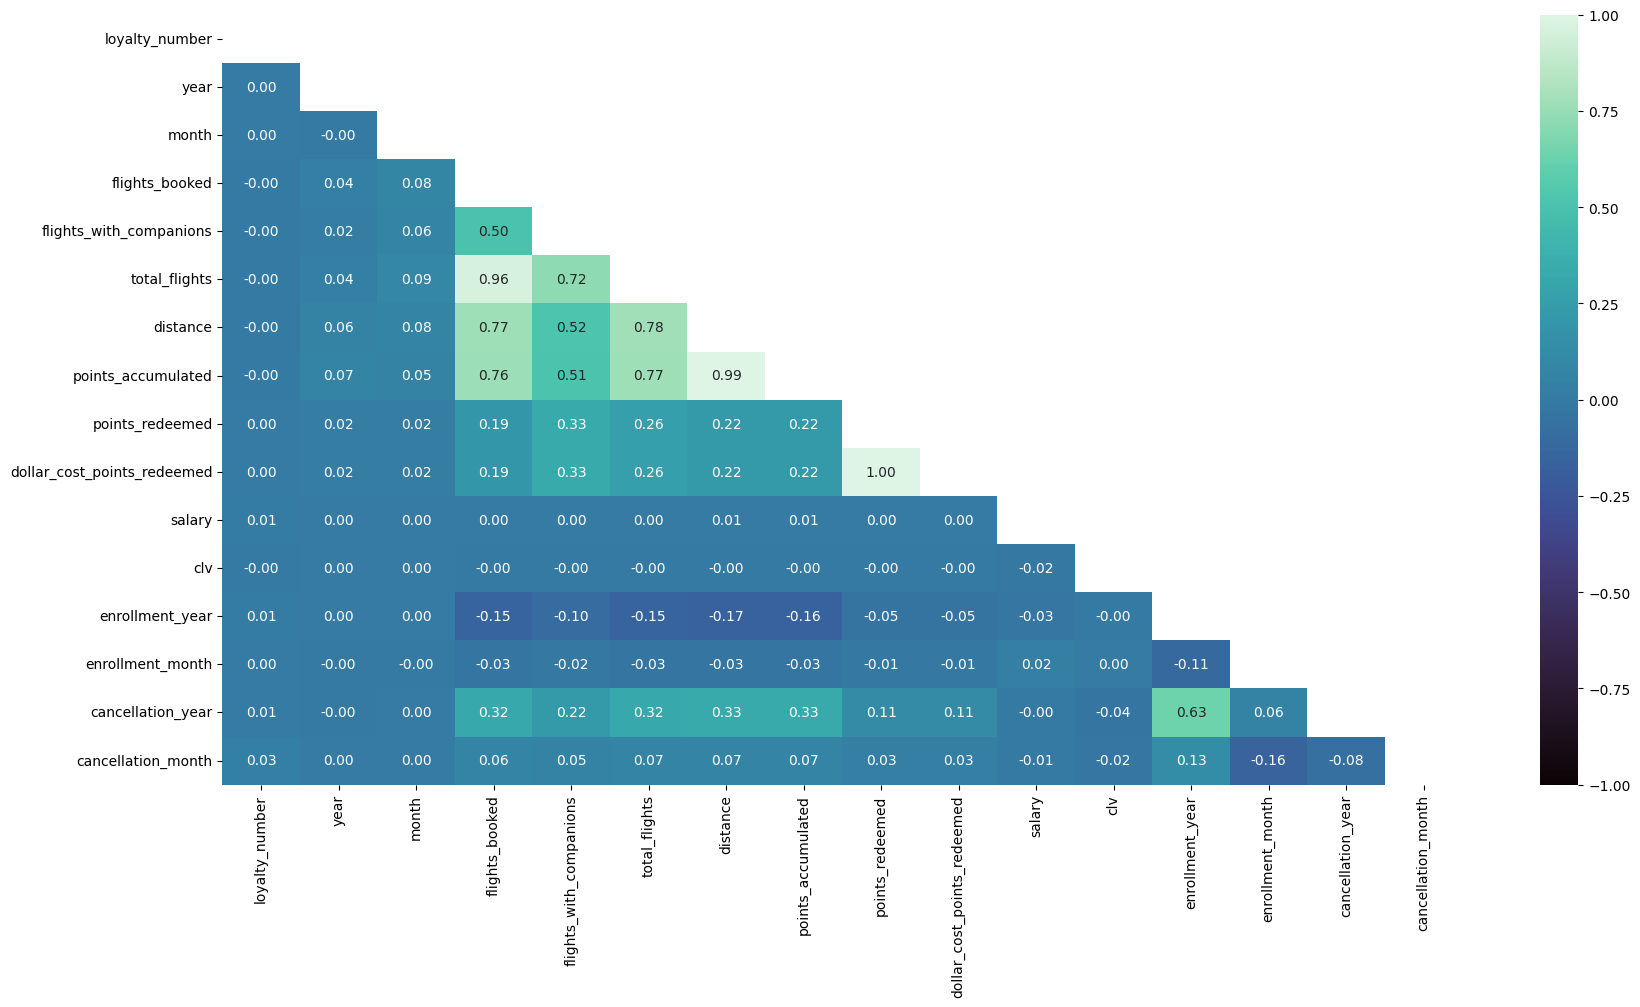

In [29]:
plt.figure(figsize=(20,10))

mascara = np.triu(np.ones_like(df_unido.corr(numeric_only=True), dtype=bool))    

sns.heatmap(df_unido.corr(numeric_only=True), annot=True, fmt=".2f",cmap="mako",vmin=-1, vmax=1, mask=mascara);

In [ ]:
# Observación:
# tiene sentido que la correlacion entre points_accumulated y distance sea alta, esto indica que son variables que van de la mano (actividad de vuelo) y si una aumenta la otra tambien, 
# posiblemente se maneja un programa de fidelizacion donde se acumulan puntos dependiendo de la distancia recorrida

# me llama la atencion que la variable salary no tenga una correlacion alta con alguna variable, (con clv por ejemplo)

# 2) Análisis Estadístico:

In [39]:
df_unido.describe(include="object").T

,count,unique,top,freq
country,403760,1,Canada,403760
province,403760,11,Ontario,130258
city,403760,29,Toronto,80775
postal_code,403760,55,V6E 3D9,21944
gender,403760,2,Female,202757
education,403760,5,Bachelor,252567
marital_status,403760,3,Married,234845
loyalty_card,403760,3,Star,183745
enrollment_type,403760,2,Standard,380419


#### 1. Distribución de frecuencias de las variables categóricas relevantes.

#### Variables categóricas relevantes

* `province`
* `gender`
* `education`
* `marital_status`
* `loyalty_card`

In [45]:
variables_categoricas = ["province","gender", "education", "marital_status", "loyalty_card"]

In [46]:
for col in variables_categoricas:
    # Frecuencia absoluta
    freq_abs = df_unido[col].value_counts()

    # Frecuencia relativa (porcentaje)
    freq_rel = df_unido[col].value_counts(normalize=True) * 100

    # Mostrar resultados
    print("Frecuencia absoluta:\n", freq_abs)
    print("\nFrecuencia relativa (%):\n", freq_rel)
    print("=" * 100)

Frecuencia absoluta:
 province
Ontario                 130258
British Columbia        106442
Quebec                   79573
Alberta                  23360
Manitoba                 15900
New Brunswick            15352
Nova Scotia              12507
Saskatchewan              9861
Newfoundland              6244
Yukon                     2679
Prince Edward Island      1584
Name: count, dtype: int64

Frecuencia relativa (%):
 province
Ontario                 32.261244
British Columbia        26.362691
Quebec                  19.707995
Alberta                  5.785615
Manitoba                 3.937983
New Brunswick            3.802259
Nova Scotia              3.097632
Saskatchewan             2.442292
Newfoundland             1.546463
Yukon                    0.663513
Prince Edward Island     0.392312
Name: proportion, dtype: float64
Frecuencia absoluta:
 gender
Female    202757
Male      201003
Name: count, dtype: int64

Frecuencia relativa (%):
 gender
Female    50.217208
Male      49.782

In [ ]:
# Observación:
# Con las frecuencias podemos ver la representacion de las categorias de las variables.
# En este caso observamos que la mayor parte de los clientes se concentran en las provincias Ontario, British Columbia y Quebec.

# En cuanto al genero, están representados en partes casi iguales 

# En educación, la mayor parte de los clientes tiene un nivel de educación de Bachelor

# En estado marital el 58% son casados

# En loyalty card observamos que el 45% de los clientes son Star, seguramente el nivel mas básico.